# Project 27 - Smart Parking Demand Prediction
## Exploratory Data Analysis — 2018 On-Street Parking Sensor Data
**Author:** Prashant Thapa  
**Source:** City of Melbourne Open Data Portal

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

## 1. Load Data

In [2]:
DATA_PATH = 'data/On-street_Car_Parking_Sensor_Data_-_2018.csv'

SAMPLE_SIZE = 500_000

df = pd.read_csv(
    DATA_PATH,
    nrows=SAMPLE_SIZE,
    parse_dates=['ArrivalTime', 'DepartureTime'],
    encoding='utf-8-sig',
    low_memory=False
)

df['ArrivalTime'] = pd.to_datetime(df['ArrivalTime'], format='mixed')
df['DepartureTime'] = pd.to_datetime(df['DepartureTime'], format='mixed')
df['DurationMinutes'] = pd.to_numeric(df['DurationMinutes'], errors='coerce')

print(f'Loaded {len(df):,} rows')
df.head()

/var/folders/r7/hr18dws92fxg6mq0t1176n4r0000gn/T/ipykernel_26808/3047706846.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(
/var/folders/r7/hr18dws92fxg6mq0t1176n4r0000gn/T/ipykernel_26808/3047706846.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(


Loaded 500,000 rows


,DeviceId,ArrivalTime,DepartureTime,DurationMinutes,StreetMarker,SignPlateID,Sign,AreaName,StreetId,StreetName,BetweenStreet1ID,BetweenStreet1,BetweenStreet2ID,BetweenStreet2,SideOfStreet,SideName,BayId,InViolation,VehiclePresent
0,17297,2018-02-21 23:39:31,2018-02-21 23:41:49,2.0,13254N,NaN,NaN,Docklands,123,BOURKE STREET,998,MERCHANT STREET,558,CUMBERLAND STREET,3,North,6182,False,True
1,17298,2018-03-06 08:19:57,2018-03-06 08:23:31,4.0,13256N,308.0,2P TKT A M-SAT 7:30-18:30,Docklands,123,BOURKE STREET,998,MERCHANT STREET,558,CUMBERLAND STREET,3,North,6183,False,False
2,17294,2018-01-04 09:37:23,2018-01-04 10:37:02,60.0,13252N,NaN,NaN,Docklands,123,BOURKE STREET,998,MERCHANT STREET,558,CUMBERLAND STREET,3,North,6181,False,False
3,17297,2018-01-12 14:51:42,2018-01-12 14:53:21,2.0,13254N,308.0,2P TKT A M-SAT 7:30-18:30,Docklands,123,BOURKE STREET,998,MERCHANT STREET,558,CUMBERLAND STREET,3,North,6182,False,False
4,17297,2018-10-29 19:54:18,2018-10-29 23:35:15,221.0,13254N,NaN,NaN,Docklands,123,BOURKE STREET,998,MERCHANT STREET,558,CUMBERLAND STREET,3,North,6182,False,False


## 2. Data Overview

In [3]:
print('Shape:', df.shape)
df.info()

Shape: (500000, 19)
<class 'pandas.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   DeviceId          500000 non-null  int64         
 1   ArrivalTime       500000 non-null  datetime64[us]
 2   DepartureTime     500000 non-null  datetime64[us]
 3   DurationMinutes   498968 non-null  float64       
 4   StreetMarker      500000 non-null  str           
 5   SignPlateID       358567 non-null  float64       
 6   Sign              358567 non-null  str           
 7   AreaName          500000 non-null  str           
 8   StreetId          500000 non-null  int64         
 9   StreetName        500000 non-null  str           
 10  BetweenStreet1ID  500000 non-null  int64         
 11  BetweenStreet1    500000 non-null  str           
 12  BetweenStreet2ID  500000 non-null  str           
 13  BetweenStreet2    500000 non-null  str           


In [4]:
df.describe()

,DeviceId,ArrivalTime,DepartureTime,DurationMinutes,SignPlateID,StreetId,BetweenStreet1ID,SideOfStreet,BayId
count,500000.000000,500000,500000,498968.000000,358567.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,17217.383542,2018-06-17 13:30:03.090404,2018-06-17 14:19:51.136945,46.982434,290.611029,494.104928,1050.542882,3.683836,6103.409102
min,17170.000000,2018-01-01 00:00:00,2018-01-01 00:02:16,0.000000,3.000000,5.000000,5.000000,1.000000,567.000000
25%,17193.000000,2018-03-17 10:14:09.250000,2018-03-17 11:05:17.750000,3.000000,205.000000,528.000000,998.000000,3.000000,6021.000000
50%,17212.000000,2018-06-09 16:04:11.500000,2018-06-09 16:39:11,10.000000,285.000000,528.000000,1241.000000,4.000000,6036.000000
75%,17230.000000,2018-09-15 05:59:27,2018-09-15 07:30:00,40.000000,421.000000,528.000000,1285.000000,4.000000,6060.000000
max,25827.000000,2018-12-31 23:41:49,2018-12-31 23:56:53,998.000000,642.000000,1433.000000,1457.000000,5.000000,8249.000000
std,135.224898,NaN,NaN,95.325703,161.707671,135.411890,292.422077,0.495751,215.899112


## 3. Missing Values

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing': missing, 'Pct (%)': missing_pct})[missing > 0]

,Missing,Pct (%)
DurationMinutes,1032,0.21
SignPlateID,141433,28.29
Sign,141433,28.29


## 4. Parking Duration Distribution

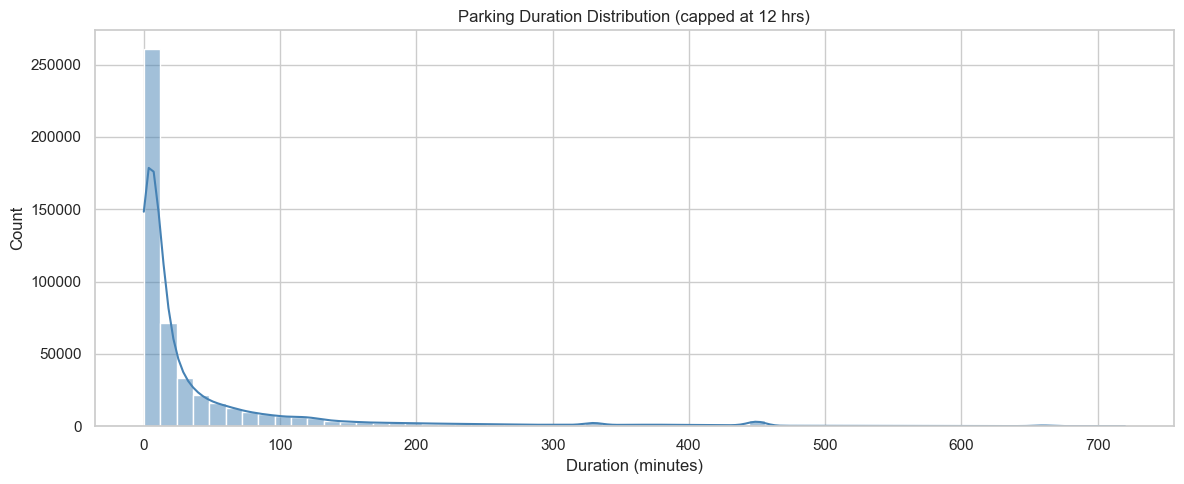

count    498450.000000
mean         46.171504
std          91.961838
min           0.000000
25%           3.000000
50%          10.000000
75%          40.000000
max         720.000000
Name: DurationMinutes, dtype: float64


In [6]:
duration = df[df['DurationMinutes'].between(0, 720)]['DurationMinutes']

plt.figure(figsize=(12, 5))
sns.histplot(duration, bins=60, kde=True, color='steelblue')
plt.title('Parking Duration Distribution (capped at 12 hrs)')
plt.xlabel('Duration (minutes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(duration.describe())

## 5. Parking Arrivals by Hour

/var/folders/r7/hr18dws92fxg6mq0t1176n4r0000gn/T/ipykernel_26808/474432908.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hourly, x='Hour', y='Arrivals', palette='Blues_d')


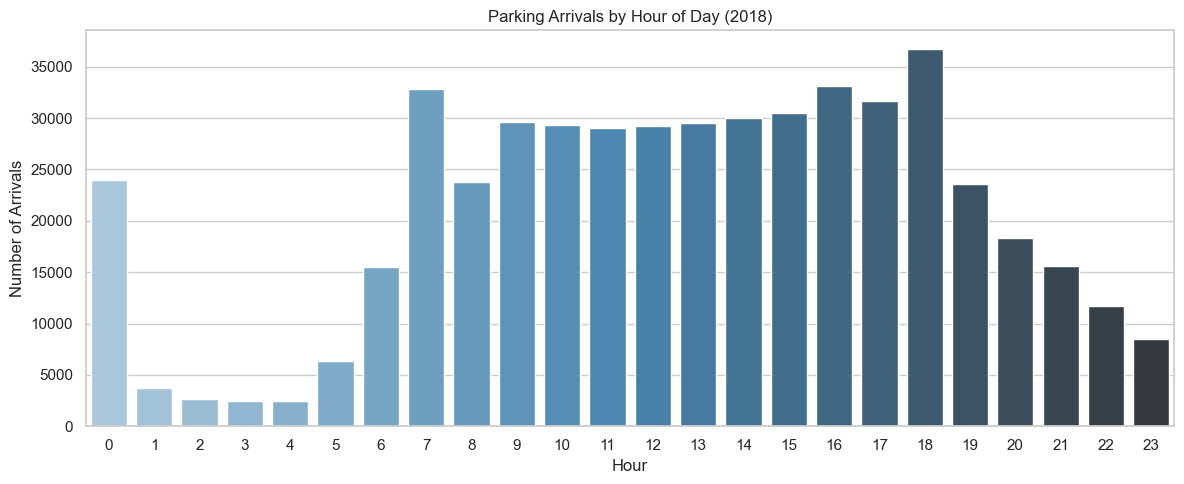

In [7]:
df['Hour'] = df['ArrivalTime'].dt.hour
hourly = df.groupby('Hour').size().reset_index(name='Arrivals')

plt.figure(figsize=(12, 5))
sns.barplot(data=hourly, x='Hour', y='Arrivals', palette='Blues_d')
plt.title('Parking Arrivals by Hour of Day (2018)')
plt.xlabel('Hour')
plt.ylabel('Number of Arrivals')
plt.tight_layout()
plt.show()

## 6. Top Areas by Parking Demand

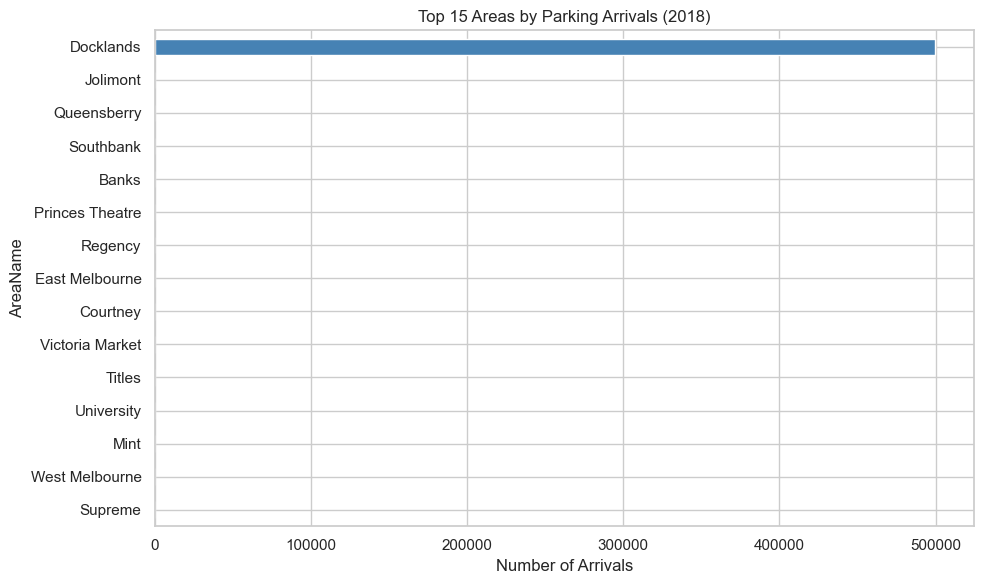

In [8]:
top_areas = df['AreaName'].value_counts().head(15)

plt.figure(figsize=(10, 6))
top_areas.plot(kind='barh', color='steelblue')
plt.title('Top 15 Areas by Parking Arrivals (2018)')
plt.xlabel('Number of Arrivals')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Key Observations
- ...